In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras 
from tensorflow.keras import layers

In [3]:
train_data_path = '/Users/srujanappu/Downloads/Fruits_Vegetables/train'
test_data_path = '/Users/srujanappu/Downloads/Fruits_Vegetables/test'
val_data_path = '/Users/srujanappu/Downloads/Fruits_Vegetables/validation'

In [4]:
img_width = 180
img_height = 180

In [5]:
data_train = tf.keras.utils.image_dataset_from_directory(
   train_data_path, shuffle = True, image_size = (img_width,img_height),
   batch_size = 32, validation_split = False 
)

Found 3115 files belonging to 36 classes.


In [38]:
data_cat = data_train.class_names
data_cat

['apple',
 'banana',
 'beetroot',
 'bell pepper',
 'cabbage',
 'capsicum',
 'carrot',
 'cauliflower',
 'chilli pepper',
 'corn',
 'cucumber',
 'eggplant',
 'garlic',
 'ginger',
 'grapes',
 'jalepeno',
 'kiwi',
 'lemon',
 'lettuce',
 'mango',
 'onion',
 'orange',
 'paprika',
 'pear',
 'peas',
 'pineapple',
 'pomegranate',
 'potato',
 'raddish',
 'soy beans',
 'spinach',
 'sweetcorn',
 'sweetpotato',
 'tomato',
 'turnip',
 'watermelon']

In [7]:
data_val = tf.keras.utils.image_dataset_from_directory(
   val_data_path, shuffle = False, image_size = (img_width,img_height),
   batch_size = 32, validation_split = False 
)

Found 351 files belonging to 36 classes.


In [8]:
data_test =tf.keras.utils.image_dataset_from_directory(
   test_data_path, shuffle = False, image_size = (img_width,img_height),
   batch_size = 32, validation_split = False 
)

Found 359 files belonging to 36 classes.


2025-07-16 22:41:10.451634: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-07-16 22:41:10.622834: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


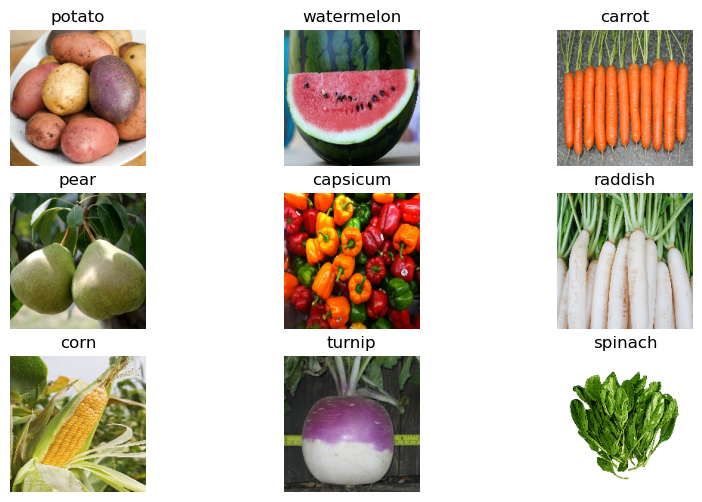

In [9]:
plt.figure(figsize = (10,6))
for image, labels in data_train.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(image[i].numpy().astype('uint8'))
        plt.title(data_cat[labels[i]])
        plt.axis('off')
        

In [10]:
from tensorflow.keras.models import Sequential
model = Sequential([
    layers.Rescaling(1./255),
    layers.Conv2D(16, 3 , padding = 'same' , activation = 'relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding = 'same', activation = 'relu'),
    layers.MaxPool2D(),
    layers.Conv2D(64, 3 , padding = 'same' , activation = 'relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(128),
    layers.Dense(len(data_cat))


])

In [11]:
model.compile(optimizer = 'adam' , loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True), metrics=['accuracy'] )

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
epochs_size = 25
history = model.fit(data_train, validation_data = data_val , epochs = epochs_size, batch_size = 32, verbose = 1)

Epoch 1/25


2025-07-16 22:41:11.388257: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-07-16 22:41:11.434673: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-07-16 22:41:11.592630: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile


 5/98 ━━━━━━━━━━━━━━━━━━━━ 16s 178ms/step - accuracy: 0.0481 - loss: 5.3556

2025-07-16 22:41:12.233089: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile


18/98 ━━━━━━━━━━━━━━━━━━━━ 14s 182ms/step - accuracy: 0.0400 - loss: 4.7302

...

93/98 ━━━━━━━━━━━━━━━━━━━━ 1s 254ms/step - accuracy: 0.9809 - loss: 0.0744

2025-07-16 22:50:46.237805: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile


98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.9808 - loss: 0.0753

2025-07-16 22:50:47.986683: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile
2025-07-16 22:50:48.329389: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile


98/98 ━━━━━━━━━━━━━━━━━━━━ 27s 270ms/step - accuracy: 0.9808 - loss: 0.0755 - val_accuracy: 0.9459 - val_loss: 0.4459


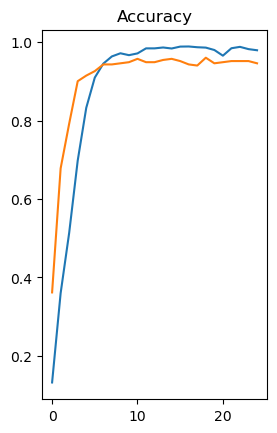

In [15]:
epoch_range = range(epochs_size)
plt.subplot(1,2,1)
plt.plot(epoch_range,history.history['accuracy'], label = 'Training Accuracy')
plt.plot(epoch_range,history.history['val_accuracy'], label = 'Validation Accuracy')
plt.title('Accuracy')
plt.show()

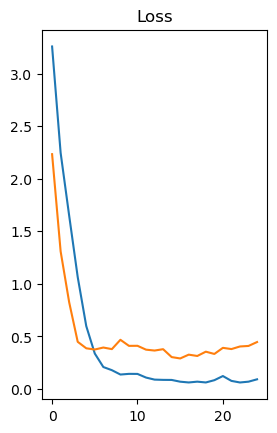

In [19]:
plt.subplot(1,2,2)
plt.plot(epoch_range,history.history['loss'], label = 'Training Loss')
plt.plot(epoch_range,history.history['val_loss'], label = 'Validation Loss')
plt.title('Loss')
plt.show()

In [26]:

image = '/Users/srujanappu/image_classification_system/app/Fruits_Vegetables/test/apple/Image_10.jpg'
image = tf.keras.utils.load_img(image, target_size=(img_height,img_width))
img_arr = tf.keras.utils.array_to_img(image)
img_batch = tf.expand_dims(img_arr,0)

In [28]:
predict = model.predict(img_batch) 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [29]:
score = tf.nn.softmax(predict)


In [35]:
label = data_cat[np.argmax(score)]
confidence  = float(np.max(score)*100)
print('Veg/Fruit in image is {} with accuracy of {:.2f}'.format(label,confidence))

Veg/Fruit in image is apple with accuracy of 94.11


In [37]:
model.save('Image_Classifier.keras')